# Project 1:

# Predicting Salaries on basis of Experience in years through Linear Regression.
######
| **Prepared by:** | Rayyan Ahmed. 
|------------------|--------------------------------------------------------------------------------|
| **Date:**        | 28th May, 2024.                                                                |


###
## Preparing DataFrame:
###

In [31]:
import pandas as pd

experience = [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5]
salary = [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189, 63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940, 91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872]

org_df = pd.DataFrame({'Experience': experience, 'Salary': salary})
org_df

,Experience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


###
## Plotting DataFrame:
###

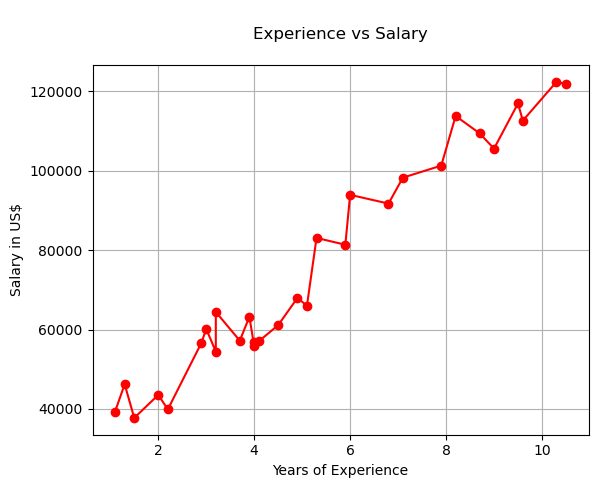

In [32]:
import matplotlib.pyplot as plt

plt.plot(org_df.Experience, org_df.Salary, marker = 'o', color = 'red')
plt.title('\nExperience vs Salary\n')
plt.xlabel('Years of Experience')
plt.ylabel('Salary in US$')
plt.grid()

###
## Seperating independent values (x) and dependent values (y):
###

In [37]:
x = org_df[['Experience']]
y = org_df['Salary']


###
## train_test_split:
###

In [39]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
x_train.shape, x_test.shape, y_train.shape, y_test.shape


((24, 1), (6, 1), (24,), (6,))

###
## Importing LinearRegression:
###

In [40]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

###
## Predicting values of unseen data (x_test): 
###

In [41]:
model.predict(x_test)

array([ 40748.96184072, 122699.62295594,  64961.65717022,  63099.14214487,
       115249.56285456, 107799.50275317])

###
## DataFrame of Actual unseen values (y_test) and Predicted unseen values (model.predict(x_test)):
###

In [42]:
pd.DataFrame({'Actual Salaries(y_test)': y_test, 'Predicted Salaries(model.predict(x_test))': model.predict(x_test)})

,Actual Salaries(y_test),Predicted Salaries(model.predict(x_test))
2,37731,40748.961841
28,122391,122699.622956
13,57081,64961.657170
10,63218,63099.142145
26,116969,115249.562855
24,109431,107799.502753


###
## Evaluating Model Performance:
###

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print(f'r2_score = {r2_score(y_test, model.predict(x_test))}')
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y_test, model.predict(x_test))}')
print(f'Mean Squared Error (MSE): {mean_squared_error(y_test, model.predict(x_test))}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, model.predict(x_test)))}')


r2_score = 0.988169515729126
Mean Absolute Error (MAE): 2446.1723690465055
Mean Squared Error (MSE): 12823412.298126549
Root Mean Squared Error (RMSE): 3580.979237321343


###
## Model Accuracy
###

In [48]:
print(f'Model Accuracy = {r2_score(y_test, model.predict(x_test)) * 100:.3f} %')

Model Accuracy = 98.817 %


###
## Predicting Program:
###

In [51]:
print('Welcome to Linear Regression based Salary Predicting Program:\n')
ask = float(input('Enter experience in years: '))
print(f'The predicted salary according to {ask} years of experience is: {model.predict([[ask]])}')


Welcome to Linear Regression based Salary Predicting Program:

Enter experience in years: 5.9
The predicted salary according to 5.9 years of experience is: [81724.29239833]


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


###
## Standardization:
###

###
## Importing Standard Scale:
###

In [53]:
from sklearn.preprocessing import StandardScaler

###
## Standardizing the orignal dataframe (org_df):
###

In [58]:
df2 = org_df.copy()
scalar = StandardScaler()
df2_scaled_ = scalar.fit_transform(df2)
df2_scaled_
df2_scaled = pd.DataFrame(df2_scaled_, columns = ['Experience (in years)','Salary (in US$)'])
df2_scaled

,Experience (in years),Salary (in US$)
0,-1.510053,-1.360113
1,-1.438373,-1.105527
2,-1.366693,-1.419919
3,-1.187494,-1.204957
4,-1.115814,-1.339781
5,-0.864935,-0.718307
6,-0.829096,-0.588158
7,-0.757416,-0.799817
8,-0.757416,-0.428810
9,-0.578216,-0.698013


###
## Seperating independent values (x) and dependent values (y) from df2_scaled:
###

In [62]:
x1 = df2_scaled[['Experience (in years)']]
y1 = df2_scaled['Salary (in US$)']


###
## train_test_split:
###

In [64]:
x1_train, x1_test, y1_train, y1_test = train_test_split( x1, y1, test_size = 0.2, random_state = 0)
y1_test

2    -1.419919
28    1.721028
13   -0.702020
10   -0.474333
26    1.519868
24    1.240203
Name: Salary (in US$), dtype: float64

###
## Importing LinearRegression:
###

In [65]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit( x1_train, y1_train)

LinearRegression()

###
## Predicting values of unseen data (x1_test): 
###

In [66]:
model1.predict(x1_test)

array([-1.30795042,  1.73247863, -0.40964184, -0.4787425 ,  1.45607599,
        1.17967335])

###
## Actual unseen values (y1_test) and Predicted unseen values (model1.predict(x1_test)):
###

In [67]:
pd.DataFrame({'Actual Value': y1_test, 'Predicted': model1.predict(x1_test)})

,Actual Value,Predicted
2,-1.419919,-1.307950
28,1.721028,1.732479
13,-0.702020,-0.409642
10,-0.474333,-0.478742
26,1.519868,1.456076
24,1.240203,1.179673


###
## Evaluating Model Performance:
###

In [77]:
print(f'r2_score = {r2_score(y1_test, model1.predict(x1_test)):.3f}')
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y1_test, model1.predict(x1_test)):.3f}')
print(f'Mean Squared Error (MSE): {mean_squared_error(y1_test, model1.predict(x1_test)):.3f}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y1_test, model1.predict(x1_test))):.3f}')

r2_score = 0.988
Mean Absolute Error (MAE): 0.091
Mean Squared Error (MSE): 0.018
Root Mean Squared Error (RMSE): 0.133


###
## Predicting Program:
###

In [71]:
# Original value = (standardized value * std) + mean

print('Welcome to Linear Regression based Salary Predicting Program:\n\nEnter any standarized value:')

ask1_ = float(input('\nEnter experience in years: '))
pred_ = model1.predict([[ask1_]])

ask1 = float(ask1_)
pred = float(pred_)

exp = (ask1 * 2.790189) + 5.3133333333333335
sal = (pred * 26953.65024877583) + 76003.0

print(f'\nResult:\nThe predicted salary according to {ask1} ({exp:.3f}) years of experience is: {pred:.3f} ({sal:.3f})')

Welcome to Linear Regression based Salary Predicting Program:

Enter any standarized value:

Enter experience in years: -1.419919	

Result:
The predicted salary according to -1.419919 (1.351) years of experience is: -1.359 (39365.958)


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


###
## Final Comparision of test dataset:
###

In [72]:
pd.DataFrame({'Actual Salaries': y_test, 'Predicted Salaries': model.predict(x_test), 'Actual Salaries(Standardized)': y1_test, 'Predicted Salaries(standardized)': model1.predict(x1_test)})

,Actual Salaries,Predicted Salaries,Actual Salaries(Standardized),Predicted Salaries(standardized)
2,37731,40748.961841,-1.419919,-1.307950
28,122391,122699.622956,1.721028,1.732479
13,57081,64961.657170,-0.702020,-0.409642
10,63218,63099.142145,-0.474333,-0.478742
26,116969,115249.562855,1.519868,1.456076
24,109431,107799.502753,1.240203,1.179673


###
## Final Comparision of train dataset:
###

In [73]:
pd.DataFrame({'Actual Salaries': y_train, 'Predicted Salaries': model.predict(x_train), 'Actual Salaries(Standarized)': y1_train, 'Predicted Salaries(standarized)': model1.predict(x1_train)})

,Actual Salaries,Predicted Salaries,Actual Salaries(Standarized),Predicted Salaries(standarized)
27,112635,116180.820367,1.359074,1.490626
11,55794,64030.399658,-0.749769,-0.444192
17,83088,76136.747322,0.262859,0.004962
22,101302,100349.442652,0.938611,0.903271
5,56642,53786.567018,-0.718307,-0.824246
16,66029,74274.232297,-0.370043,-0.064139
8,64445,56580.339556,-0.428810,-0.720595
14,61111,68686.687221,-0.552504,-0.271441
23,113812,103143.215190,1.402741,1.006922
20,91738,90105.610012,0.583780,0.523217


###
## Final Comparision of whole dataset:
###

In [74]:
pd.DataFrame({'Actual Salaries': y, 'Predicted Salaries': model.predict(x), 'Actual Salaries(Standarized)': y1, 'Predicted Salaries(standarized)': model1.predict(x1)})

,Actual Salaries,Predicted Salaries,Actual Salaries(Standarized),Predicted Salaries(standarized)
0,39343,37023.931790,-1.360113,-1.446152
1,46205,38886.446815,-1.105527,-1.377051
2,37731,40748.961841,-1.419919,-1.307950
3,43525,45405.249404,-1.204957,-1.135199
4,39891,47267.764429,-1.339781,-1.066098
5,56642,53786.567018,-0.718307,-0.824246
6,60150,54717.824531,-0.588158,-0.789695
7,54445,56580.339556,-0.799817,-0.720595
8,64445,56580.339556,-0.428810,-0.720595
9,57189,61236.627120,-0.698013,-0.547843
